In [9]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
# Several columns use 0 to mean "not recorded", which isn't a real medical value
# (e.g. BMI or Blood Pressure can't actually be 0). Treat those as missing instead.
import numpy as np

zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_as_missing:
    print(col, "zeros:", (df[col] == 0).sum())

df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

Glucose zeros: 5
BloodPressure zeros: 35
SkinThickness zeros: 227
Insulin zeros: 374
BMI zeros: 11


In [14]:
# Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]

In [15]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')

In [16]:
# Train-test split (stratified, so both sets keep the same diabetic/non-diabetic ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# Pipeline: fill missing values -> scale features -> logistic regression
# - median imputation handles the missing values we created above
# - scaling matters here because logistic regression's regularization (C) assumes
#   features are on comparable scales; Glucose (~100s) and DPF (~0-1) weren't before
# - class_weight='balanced' corrects for the 500 vs 268 class imbalance, which was
#   quietly suppressing recall on the diabetic class
model = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced'))
])

In [18]:
# Training model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross validation (stratified, so every fold keeps the same class balance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
print("\nCross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Accuracy: 0.7338

Confusion Matrix:
[[75 25]
 [16 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154


Cross-validation scores: [0.72077922 0.81818182 0.77272727 0.73856209 0.69281046]
Mean accuracy: 0.7486121721415839


In [20]:
# Sanity check for over/underfitting: train accuracy vs test accuracy.
# A big gap would mean overfitting; both being low and close means the model
# is about as good as these features allow.
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Gap:            {train_acc - test_acc:.4f}")

Train accuracy: 0.7606
Test accuracy:  0.7338
Gap:            0.0268


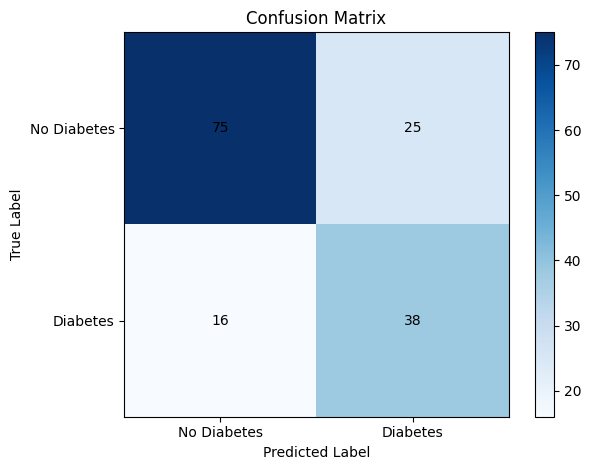

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Define your class labels (change according to your problem)
labels = ["No Diabetes", "Diabetes"]   # e.g. ["Cat", "Dog"]

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add ticks and labels
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [22]:
# Retrain on 100% of the data for deployment (more data = a better final model),
# using the same pipeline validated above
final_model = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(C=0.5, max_iter=2000, class_weight='balanced'))
])
final_model.fit(X, y)

# Saving model Pkl File
# NOTE: this single file contains the imputer + scaler + classifier together,
# so app.py can just call model.predict() / model.predict_proba() directly.
import pickle
with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(final_model, f)